This is a notebook for implementing a bayesian CNN using:
https://goodboychan.github.io/python/coursera/tensorflow_probability/icl/2021/08/26/01-Bayesian-Convolutional-Neural-Network.html

The idea from here is to use visualization methods from the various probabilities of the bayesian model to analyze how the model sees things when it is uncertain about a prediction

These are the imports we will be using

In [17]:
import tensorflow as tf
import tensorflow_probability as tfp

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import RMSprop

import numpy as np
import os
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline

from tensorflow.keras.layers import InputLayer

import h5py

tf.random.set_seed(0)

inputX = 28
inputY = 28
inputZ = 1

tfd = tfp.distributions
tfpl = tfp.layers

This cell is used to load the training data
In this case we use Mnist and a variation with various corruptions to try and confuse the model at what it's looking at

https://www.tensorflow.org/datasets/catalog/mnist_corrupted


In [9]:
def load_mnist():
    # Load MNIST from TensorFlow
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    # Normalize and expand dims for channels
    x_train = (1 - x_train / 255.).astype(np.float32)[..., np.newaxis]
    x_test = (1 - x_test / 255.).astype(np.float32)[..., np.newaxis]
    y_train_oh = tf.keras.utils.to_categorical(y_train)
    y_test_oh = tf.keras.utils.to_categorical(y_test)
    return (x_train, y_train, y_train_oh), (x_test, y_test, y_test_oh)


def load_mnist_c(data_dir):
    # Load corrupted MNIST (like spatter or other corruption types)
    x_train = np.load(os.path.join(data_dir, 'train_images.npy'))
    y_train = np.load(os.path.join(data_dir, 'train_labels.npy'))
    x_test = np.load(os.path.join(data_dir, 'test_images.npy'))
    y_test = np.load(os.path.join(data_dir, 'test_labels.npy'))

    # Normalize and expand dims
    x_train = (1 - x_train / 255.).astype(np.float32)
    x_test = (1 - x_test / 255.).astype(np.float32)
    y_train_oh = tf.keras.utils.to_categorical(y_train)
    y_test_oh = tf.keras.utils.to_categorical(y_test)
    return (x_train, y_train, y_train_oh), (x_test, y_test, y_test_oh)

We can use this function to quickly inspect the images from our datasets

In [10]:
def inspect_images(data, num_images):
    fig, ax = plt.subplots(nrows=1, ncols=num_images, figsize=(2*num_images, 2))
    for i in range(num_images):
        ax[i].imshow(data[i, ..., 0], cmap='gray')
        ax[i].axis('off')
    plt.show()

This block below will run the function to visualize our examples and also load our data into variables that we will be using

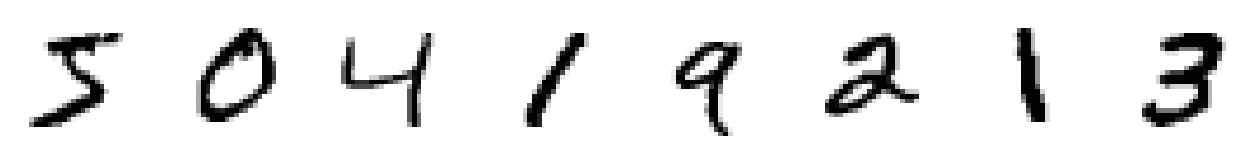

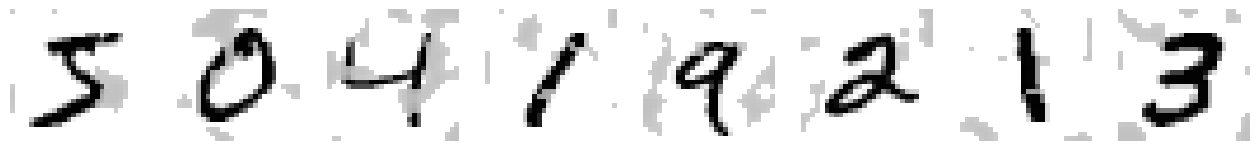

In [11]:
# Load clean MNIST
(x_train, y_train, y_train_oh), (x_test, y_test, y_test_oh) = load_mnist()
inspect_images(data=x_train, num_images=8)

# Load corrupted MNIST-C from your directory
mnist_c_dir = r'C:\Users\Michael\Desktop\UOG_Research_2025\CNN\DataSet\Mnist_C'
(x_c_train, y_c_train, y_c_train_oh), (x_c_test, y_c_test, y_c_test_oh) = load_mnist_c(mnist_c_dir)
inspect_images(data=x_c_train, num_images=8)

The code snippet below here uses a spike and slab distribution

In [12]:
def spike_and_slab(event_shape, dtype):
    distribution = tfd.Mixture(
        cat=tfd.Categorical(probs=[0.5, 0.5]),
        components=[
            tfd.Independent(tfd.Normal(
                loc=tf.zeros(event_shape, dtype=dtype),
                scale=1.0*tf.ones(event_shape, dtype=dtype)),
                            reinterpreted_batch_ndims=1),
            tfd.Independent(tfd.Normal(
                loc=tf.zeros(event_shape, dtype=dtype),
                scale=10.0*tf.ones(event_shape, dtype=dtype)),
                            reinterpreted_batch_ndims=1)],
    name='spike_and_slab')
    return distribution

This code will visualize our spike and slab distribution which is used for our prior distribution when getting the prior

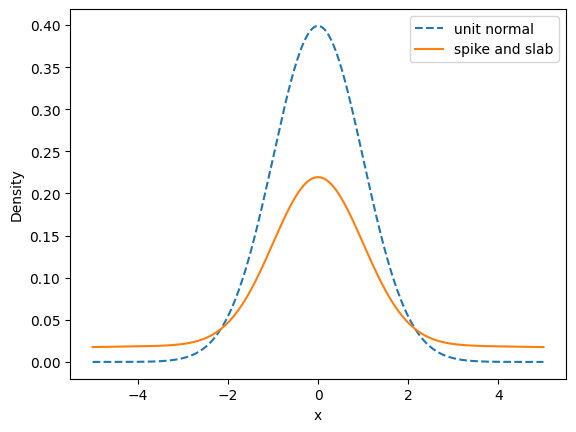

In [13]:
x_plot = np.linspace(-5, 5, 1000)[:, np.newaxis]
plt.plot(x_plot, tfd.Normal(loc=0, scale=1).prob(x_plot).numpy(), label='unit normal', linestyle='--')
plt.plot(x_plot, spike_and_slab(1, dtype=tf.float32).prob(x_plot).numpy(), label='spike and slab')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

This code block below will create our CNN model

It contains all the needed code for the methods along with the model itself

The model contains 2 Bayesian Conv2d layers, maxing pooling 2d, a dense layer and then the output as a distribution 

In [14]:
def nll(y_true, y_pred):
    """
    This function should return the negative log-likelihood of each sample
    in y_true given the predicted distribution y_pred. If y_true is of shape
    [B, E] and y_pred has batch shape [B] and event_shape [E], the output
    should be a Tensor of shape [B].
    """

    return -y_pred.log_prob(y_true)

def get_convolutional_reparameterization_layer(filters, kernel_size, divergence_fn):
     layer = tfpl.Convolution2DReparameterization(
        filters=filters,
        kernel_size=kernel_size,
        activation='relu',
        padding='VALID',  # Preserves spatial resolution
        kernel_prior_fn=tfpl.default_multivariate_normal_fn,
        kernel_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
        kernel_divergence_fn=divergence_fn,
        bias_prior_fn=tfpl.default_multivariate_normal_fn,
        bias_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
        bias_divergence_fn=divergence_fn
    )

     return layer


def spike_and_slab(event_shape, dtype):
    distribution = tfd.Mixture(
        cat=tfd.Categorical(probs=[0.5, 0.5]),
        components=[
            tfd.Independent(tfd.Normal(
                loc=tf.zeros(event_shape, dtype=dtype),
                scale=1.0*tf.ones(event_shape, dtype=dtype)),
                            reinterpreted_batch_ndims=1),
            tfd.Independent(tfd.Normal(
                loc=tf.zeros(event_shape, dtype=dtype),
                scale=10.0*tf.ones(event_shape, dtype=dtype)),
                            reinterpreted_batch_ndims=1)],
    name='spike_and_slab')
    return distribution

def get_prior(kernel_size, bias_size, dtype=None):
    """
    This function should create the prior distribution, consisting of the
    "spike and slab" distribution that is described above.
    The distribution should be created using the kernel_size, bias_size and dtype
    function arguments above.
    The function should then return a callable, that returns the prior distribution.
    """
    n = kernel_size+bias_size
    prior_model = Sequential([tfpl.DistributionLambda(lambda t : spike_and_slab(n, dtype))])
    return prior_model

def get_posterior(kernel_size, bias_size, dtype=None):
    """
    This function should create the posterior distribution as specified above.
    The distribution should be created using the kernel_size, bias_size and dtype
    function arguments above.
    The function should then return a callable, that returns the posterior distribution.
    """
    n = kernel_size + bias_size
    return Sequential([
        tfpl.VariableLayer(tfpl.IndependentNormal.params_size(n), dtype=dtype),
        tfpl.IndependentNormal(n)
    ])

def get_dense_variational_layer(prior_fn, posterior_fn, kl_weight):
    """
    This function should create an instance of a DenseVariational layer according
    to the above specification.
    The function takes the prior_fn, posterior_fn and kl_weight as arguments, which should
    be used to define the layer.
    Your function should then return the layer instance.
    """
    return tfpl.DenseVariational(
        units=10, make_posterior_fn=posterior_fn, make_prior_fn=prior_fn, kl_weight=kl_weight
    )

divergence_fn = lambda q, p, _ : tfd.kl_divergence(q, p) / x_train.shape[0]

dense_variational_layer = get_dense_variational_layer(
    get_prior, get_posterior, kl_weight=1/x_train.shape[0]
)

bayesian_model = Sequential([
    # convolutional_reparameterization_layer,
    InputLayer(input_shape=(inputX, inputY, inputZ)),
    get_convolutional_reparameterization_layer(filters=8, kernel_size=(3, 3), divergence_fn=divergence_fn),
    get_convolutional_reparameterization_layer(filters=16, kernel_size=(3, 3), divergence_fn=divergence_fn),
    # get_convolutional_reparameterization_layer(filters=32, kernel_size=(1, 1), divergence_fn=divergence_fn),
    MaxPooling2D(pool_size=(3, 3)),
    Flatten(),
    dense_variational_layer,
    tfpl.OneHotCategorical(10) # , convert_to_tensor_fn=tfd.Distribution.mode
])

bayesian_model.compile(loss=nll,
              optimizer=RMSprop(),
              metrics=['accuracy'],
              experimental_run_tf_function=False)

bayesian_model.summary()

C:\Users\Michael\Desktop\UOG_Research_2025\CNN\.venv\lib\site-packages\tensorflow_probability\python\layers\util.py:102: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  trainable=trainable)
C:\Users\Michael\Desktop\UOG_Research_2025\CNN\.venv\lib\site-packages\tensorflow_probability\python\layers\util.py:112: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  trainable=trainable)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_reparameterization (  (None, 26, 26, 8)        160       
 Conv2DReparameterization)                                       
                                                                 
 conv2d_reparameterization_1  (None, 24, 24, 16)       2336      
  (Conv2DReparameterization)                                     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 8, 8, 16)         0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 1024)              0         
                                                                 
 dense_variational (DenseVar  (None, 10)               20500     
 iational)                                              

This will begin training and fitting the model

In [15]:

bayesian_model.fit(x=x_train, y=y_train_oh, epochs=5, verbose=True)

Epoch 1/5
1875/1875 [==============================] - 33s 16ms/step - loss: 1.8325 - accuracy: 0.3530
Epoch 2/5
1875/1875 [==============================] - 31s 16ms/step - loss: 0.5076 - accuracy: 0.8127
Epoch 3/5
1875/1875 [==============================] - 33s 17ms/step - loss: 0.3230 - accuracy: 0.8875
Epoch 4/5
1875/1875 [==============================] - 33s 17ms/step - loss: 0.2665 - accuracy: 0.9144
Epoch 5/5
1875/1875 [==============================] - 32s 17ms/step - loss: 0.2451 - accuracy: 0.9283


This will evaluate the model on the datasets

In [16]:
print('Accuracy on MNIST test set: ',
      str(bayesian_model.evaluate(x_test, y_test_oh, verbose=False)[1]))
print('Accuracy on corrupted MNIST test set: ',
      str(bayesian_model.evaluate(x_c_test, y_c_test_oh, verbose=False)[1]))

Accuracy on MNIST test set:  0.9325000047683716
Accuracy on corrupted MNIST test set:  0.8962000012397766


Now that we have a working model, we will run various statistical tests to analyze our models uncertainty with various inputs

The variables below will be used to create a sample for our testing, we wont use all the data just yet but we can easily adjust it to use more

Each test image will be run 200 times to ensure that the outputs we are getting are consistent.

In [30]:
# how many times we run each test image
num_passes = 200

# How many test images to use
num_samples = 5
num_classes = 10

This will just be our temporary storage for everything

In [31]:
predicted_labels = np.zeros((num_samples, num_passes), dtype=np.int32)
predicted_probs = np.zeros((num_samples, num_passes, num_classes), dtype=np.float32)
correct_labels = np.argmax(y_c_test_oh[:num_samples], axis=1)
gradcam_maps = np.zeros((num_samples, num_passes, 26, 26), dtype=np.float32)  # Update shape if needed
softmax_entropy = np.zeros((num_samples, num_passes), dtype=np.float32)
predictive_entropy = np.zeros(num_samples, dtype=np.float32)
mutual_information = np.zeros(num_samples, dtype=np.float32)

This will run the tests and save everything in an h5 file so we can easily parse it later as needed

In [32]:
def compute_gradcam(model, image, class_index, target_layer):
    image = tf.convert_to_tensor(image[np.newaxis, ...])

    grad_model = tf.keras.models.Model(
        [model.input],
        [target_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        if isinstance(predictions, tfd.Distribution):
            predictions = predictions.mean()
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Weight the conv outputs
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap + 1e-8)
    return heatmap.numpy()

# This will automatically find the last conv2d layer
target_layer = next(layer for layer in bayesian_model.layers 
                    if isinstance(layer, tfp.layers.Convolution2DReparameterization))

all_probs = np.zeros((num_passes, num_samples, num_classes), dtype=np.float32)

for i in range(num_passes):
    
    print(f"{i} / {num_passes}")
    
    # Batch prediction for num_samples images
    preds = bayesian_model(x_c_test[:num_samples], training=True)
    
    probs = preds.mean().numpy()
    
    predicted_labels[:, i] = np.argmax(probs, axis=1)
    predicted_probs[:, i, :] = probs
    all_probs[i] = probs
    softmax_entropy[:, i] = -np.sum(probs * np.log(probs + 1e-8), axis=1)

    for j in range(num_samples):
        # print(f"{j} / {num_samples}")
        
        heatmap = compute_gradcam(bayesian_model, x_c_test[j], predicted_labels[j, i], target_layer)
        gradcam_maps[j, i] = heatmap

# Compute final uncertainty metrics
mean_probs = np.mean(all_probs, axis=0)
predictive_entropy[:] = -np.sum(mean_probs * np.log(mean_probs + 1e-8), axis=1)
expected_entropy = np.mean(softmax_entropy, axis=1)
mutual_information[:] = predictive_entropy - expected_entropy

# Save to HDF5
with h5py.File("bayesian_uncertainty_results.h5", "w") as f:
    f.create_dataset("predicted_labels", data=predicted_labels)
    f.create_dataset("predicted_probs", data=predicted_probs)
    f.create_dataset("correct_labels", data=correct_labels)
    f.create_dataset("gradcam_maps", data=gradcam_maps)
    f.create_dataset("softmax_entropy", data=softmax_entropy)
    f.create_dataset("predictive_entropy", data=predictive_entropy)
    f.create_dataset("mutual_information", data=mutual_information)
    f.create_dataset("input_images", data=x_c_test[:num_samples])

0 / 200
1 / 200
2 / 200
3 / 200
4 / 200
5 / 200
6 / 200
7 / 200
8 / 200
9 / 200
10 / 200
11 / 200
12 / 200
13 / 200
14 / 200
15 / 200
16 / 200
17 / 200
18 / 200
19 / 200
20 / 200
21 / 200
22 / 200
23 / 200
24 / 200
25 / 200
26 / 200
27 / 200
28 / 200
29 / 200
30 / 200
31 / 200
32 / 200
33 / 200
34 / 200
35 / 200
36 / 200
37 / 200
38 / 200
39 / 200
40 / 200
41 / 200
42 / 200
43 / 200
44 / 200
45 / 200
46 / 200
47 / 200
48 / 200
49 / 200
50 / 200
51 / 200
52 / 200
53 / 200
54 / 200
55 / 200
56 / 200
57 / 200
58 / 200
59 / 200
60 / 200
61 / 200
62 / 200
63 / 200
64 / 200
65 / 200
66 / 200
67 / 200
68 / 200
69 / 200
70 / 200
71 / 200
72 / 200
73 / 200
74 / 200
75 / 200
76 / 200
77 / 200
78 / 200
79 / 200
80 / 200
81 / 200
82 / 200
83 / 200
84 / 200
85 / 200
86 / 200
87 / 200
88 / 200
89 / 200
90 / 200
91 / 200
92 / 200
93 / 200
94 / 200
95 / 200
96 / 200
97 / 200
98 / 200
99 / 200
100 / 200
101 / 200
102 / 200
103 / 200
104 / 200
105 / 200
106 / 200
107 / 200
108 / 200
109 / 200
110 / 200


This will now output all the fancy charts we use to analyze our results

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

This will load our h5 file that we saved

In [53]:
# Load all data from HDF5
with h5py.File("bayesian_uncertainty_results.h5", "r") as f:
    predicted_labels = f["predicted_labels"][:]           # [num_samples, num_passes]
    predicted_probs = f["predicted_probs"][:]             # [num_samples, num_passes, num_classes]
    correct_labels = f["correct_labels"][:]               # [num_samples]
    gradcam_maps = f["gradcam_maps"][:]                   # [num_samples, num_passes, height, width]
    softmax_entropy = f["softmax_entropy"][:]             # [num_samples, num_passes]
    predictive_entropy = f["predictive_entropy"][:]       # [num_samples]
    mutual_information = f["mutual_information"][:]       # [num_samples]
    input_images = f["input_images"][:]                   # [num_samples, H, W, C]

This will visualize a single image result

In [120]:
def visualize_image_result(index):
    img = input_images[index]
    gradcams = gradcam_maps[index]  # Shape: (N_passes, H, W)
    mean_gradcam = np.mean(gradcams, axis=0)

    # Dispersion measures
    pixel_variance = np.var(gradcams, axis=0)
    pixel_std = np.std(gradcams, axis=0)
    pixel_range = np.max(gradcams, axis=0) - np.min(gradcams, axis=0)
    q75 = np.percentile(gradcams, 75, axis=0)
    q25 = np.percentile(gradcams, 25, axis=0)
    pixel_iqr = q75 - q25
    pixel_mad = np.mean(np.abs(gradcams - mean_gradcam), axis=0)

    mean_prob = np.mean(predicted_probs[index], axis=0)
    pred_label = np.argmax(mean_prob)
    true_label = correct_labels[index]
    correct = (pred_label == true_label)

    y_mean = np.mean(predicted_probs[index], axis=0)
    y_sigma = np.std(predicted_probs[index], axis=0)

    fig, axes = plt.subplots(4, 2, figsize=(14, 20), facecolor='white')
    fig.suptitle(f"Image {index} - {'Correct' if correct else 'Incorrect'}", fontsize=16,
                 color='green' if correct else 'red')

    # Row 0
    axes[0, 0].imshow(np.mean(img, axis=-1), cmap='gray')
    axes[0, 0].set_title("Original Image (Grayscale)")
    axes[0, 0].axis("off")

    im = axes[0, 1].imshow(mean_gradcam, cmap='plasma')
    axes[0, 1].set_title("Average Grad-CAM Overlay")
    axes[0, 1].axis("off")
    fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

    # Row 1
    im = axes[1, 0].imshow(pixel_variance, cmap='plasma')
    axes[1, 0].set_title("Grad-CAM Variance")
    axes[1, 0].axis("off")
    fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

    im = axes[1, 1].imshow(pixel_std, cmap='plasma')
    axes[1, 1].set_title("Grad-CAM Std Dev")
    axes[1, 1].axis("off")
    fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

    # Row 2
    im = axes[2, 0].imshow(pixel_iqr, cmap='plasma')
    axes[2, 0].set_title("Grad-CAM IQR (75th - 25th)")
    axes[2, 0].axis("off")
    fig.colorbar(im, ax=axes[2, 0], fraction=0.046, pad=0.04)

    im = axes[2, 1].imshow(pixel_mad, cmap='plasma')
    axes[2, 1].set_title("Grad-CAM Mean Absolute Deviation (MAD)")
    axes[2, 1].axis("off")
    fig.colorbar(im, ax=axes[2, 1], fraction=0.046, pad=0.04)

    # Row 3
    sns.barplot(x=np.arange(len(mean_prob)), y=mean_prob, ax=axes[3, 0], color='skyblue')
    axes[3, 0].set_title("Mean Predicted Class Distribution")
    axes[3, 0].scatter(true_label, mean_prob[true_label], color='green', s=100, label='True Label', marker='o', zorder=10)
    axes[3, 0].scatter(pred_label, mean_prob[pred_label], color='red', s=25, label='Predicted Label', marker='X', zorder=10)
    axes[3, 0].legend()
    axes[3, 0].set_facecolor('white')

    X_test = np.arange(len(mean_prob))
    axes[3, 1].plot(X_test, y_mean, 'r-', label='Predictive Mean')
    axes[3, 1].fill_between(X_test, y_mean + 2 * y_sigma, y_mean - 2 * y_sigma,
                            alpha=0.5, label='Epistemic Uncertainty (±2 std devs)', color='orange')
    axes[3, 1].scatter(X_test, mean_prob, marker='+', label='Mean Predicted Probabilities', color='blue')
    axes[3, 1].set_title("Prediction with Uncertainty")
    axes[3, 1].set_xlabel("Class Index")
    axes[3, 1].set_ylabel("Probability")
    axes[3, 1].legend()
    axes[3, 1].set_facecolor('white')

    plt.tight_layout()
    plt.show()


Loop through all the images showing the charts

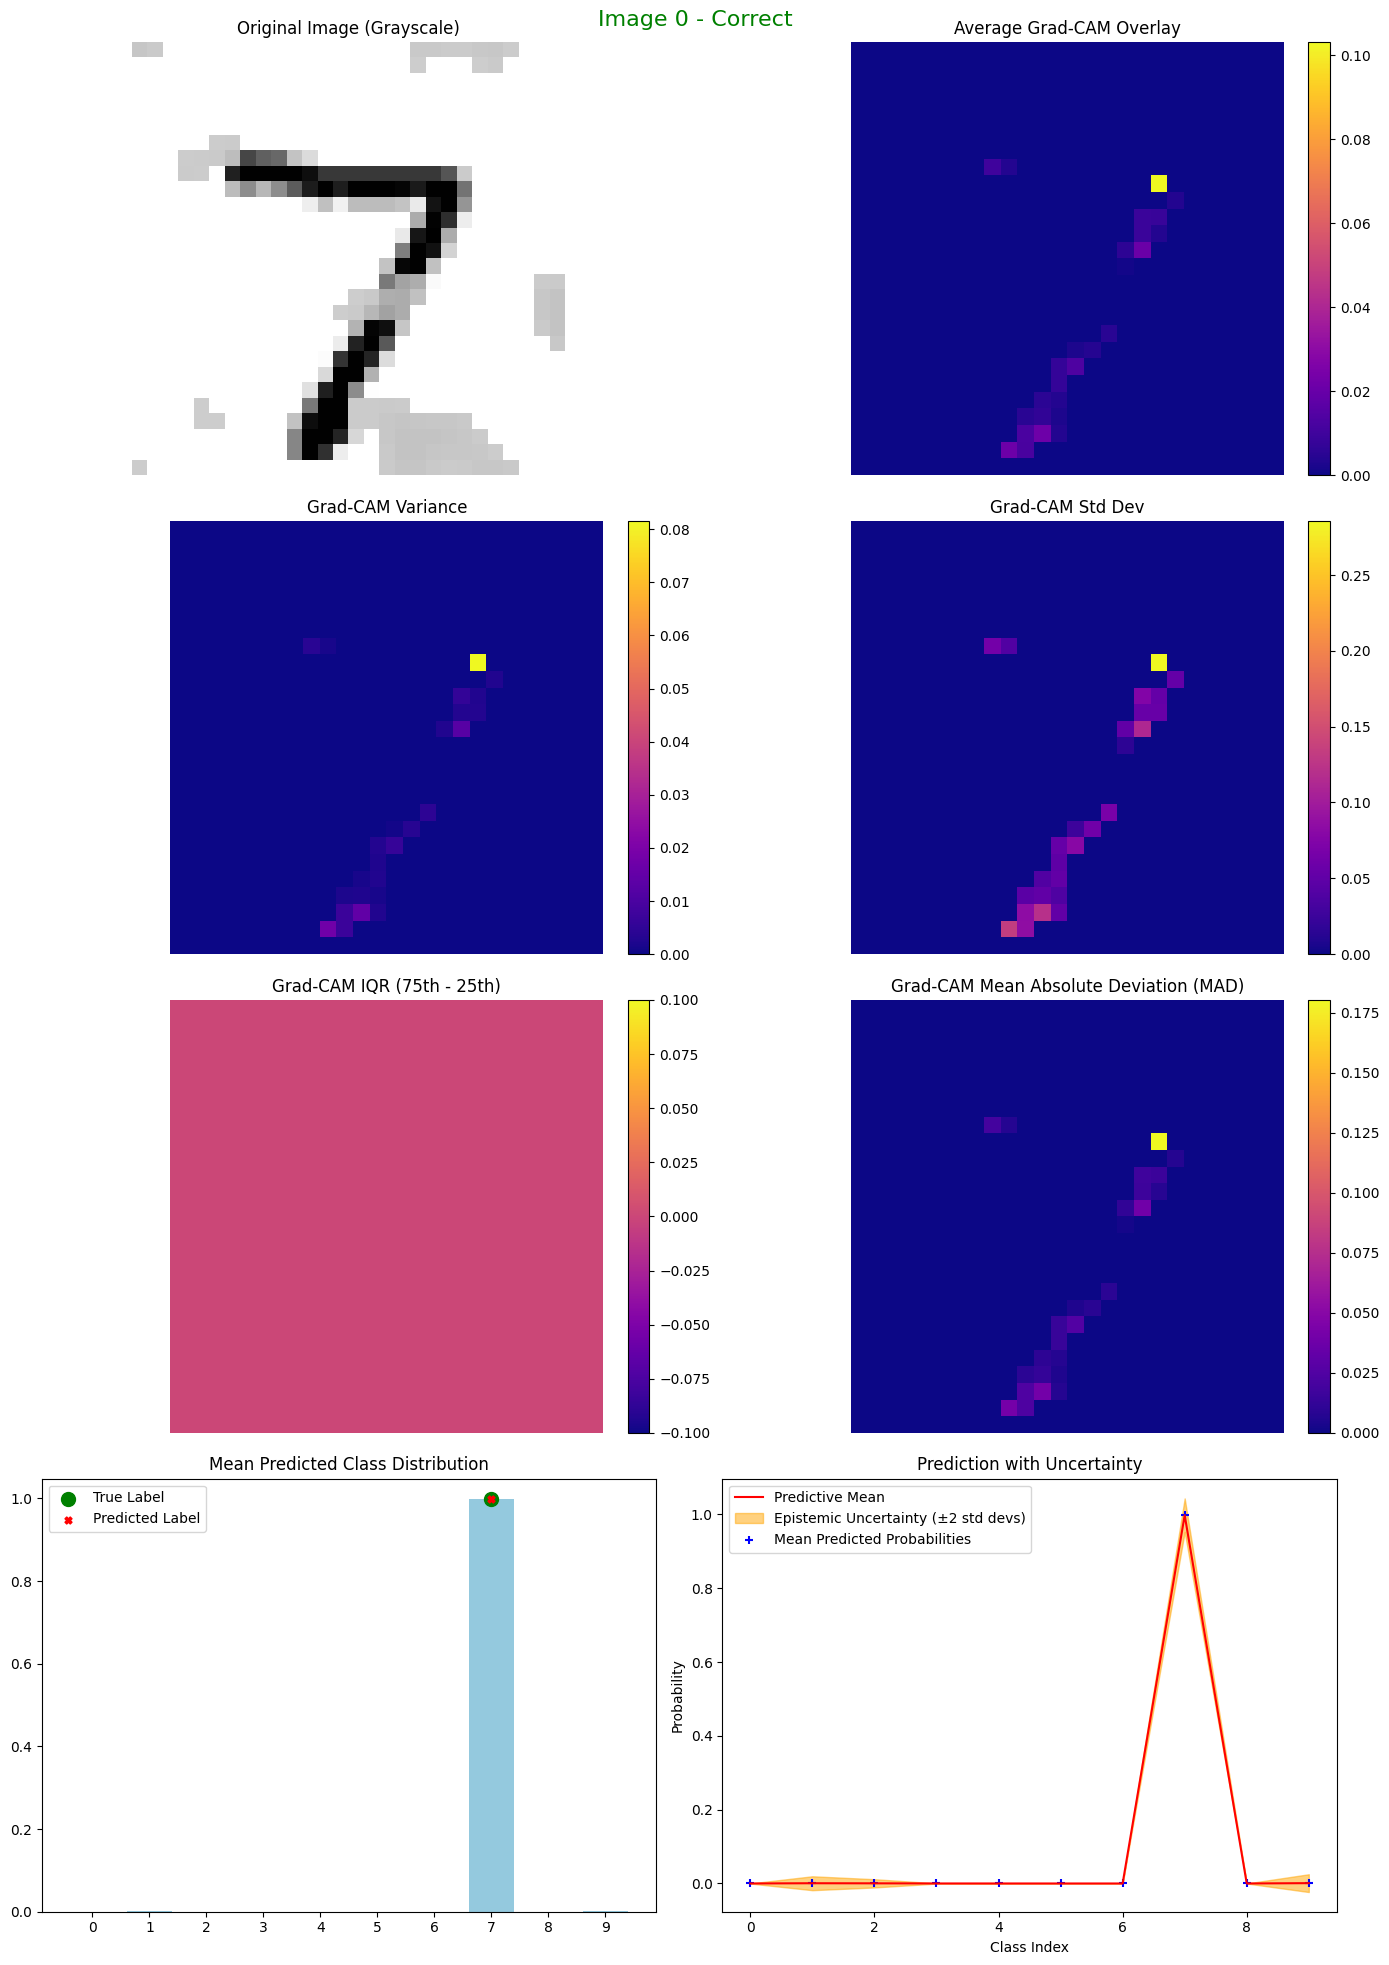

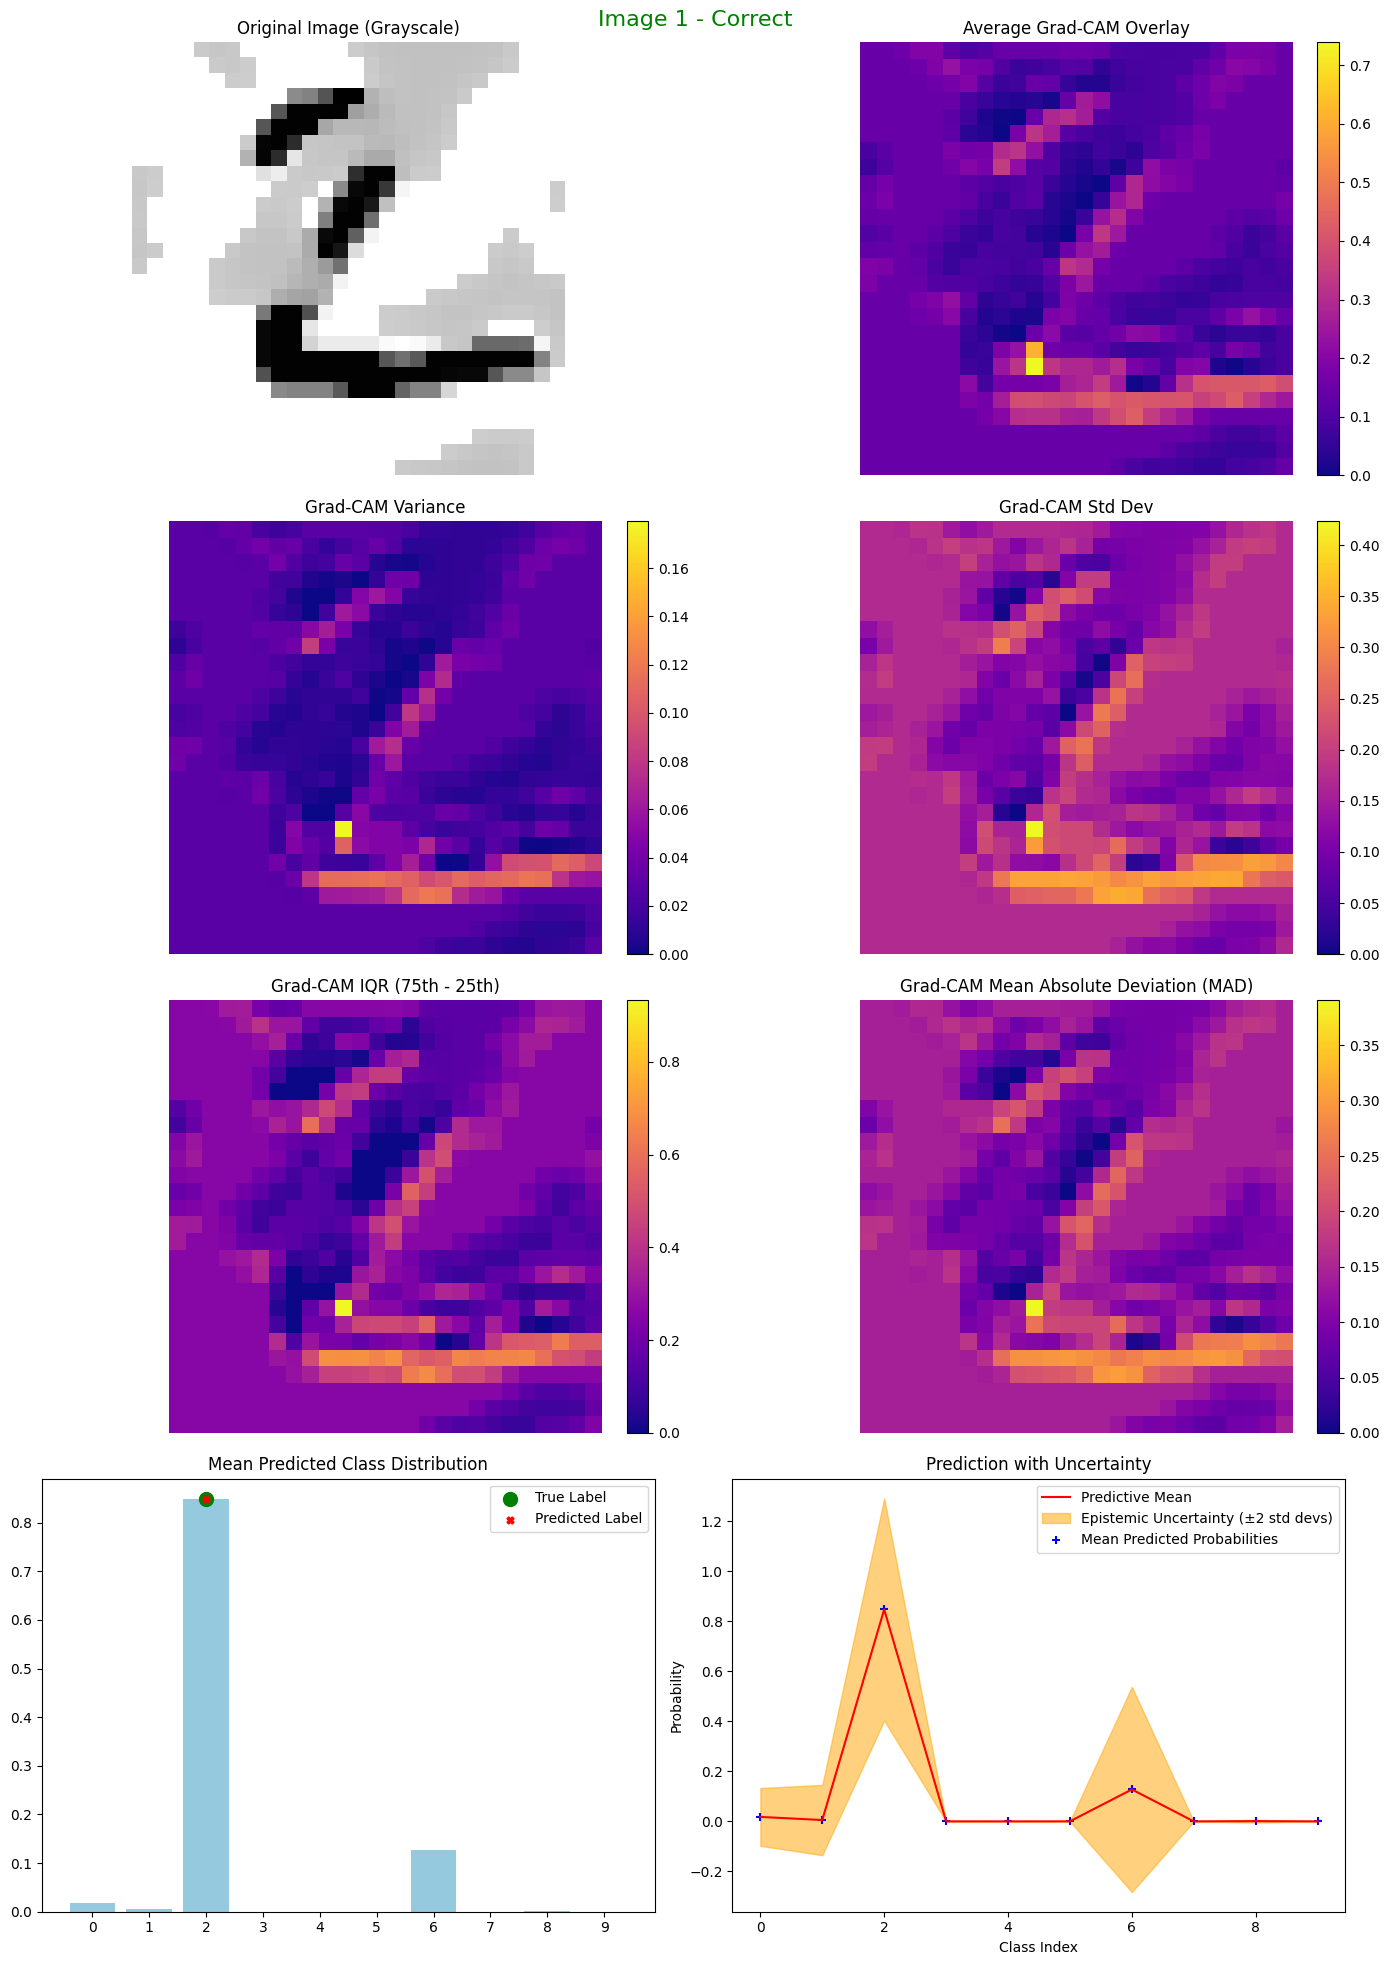

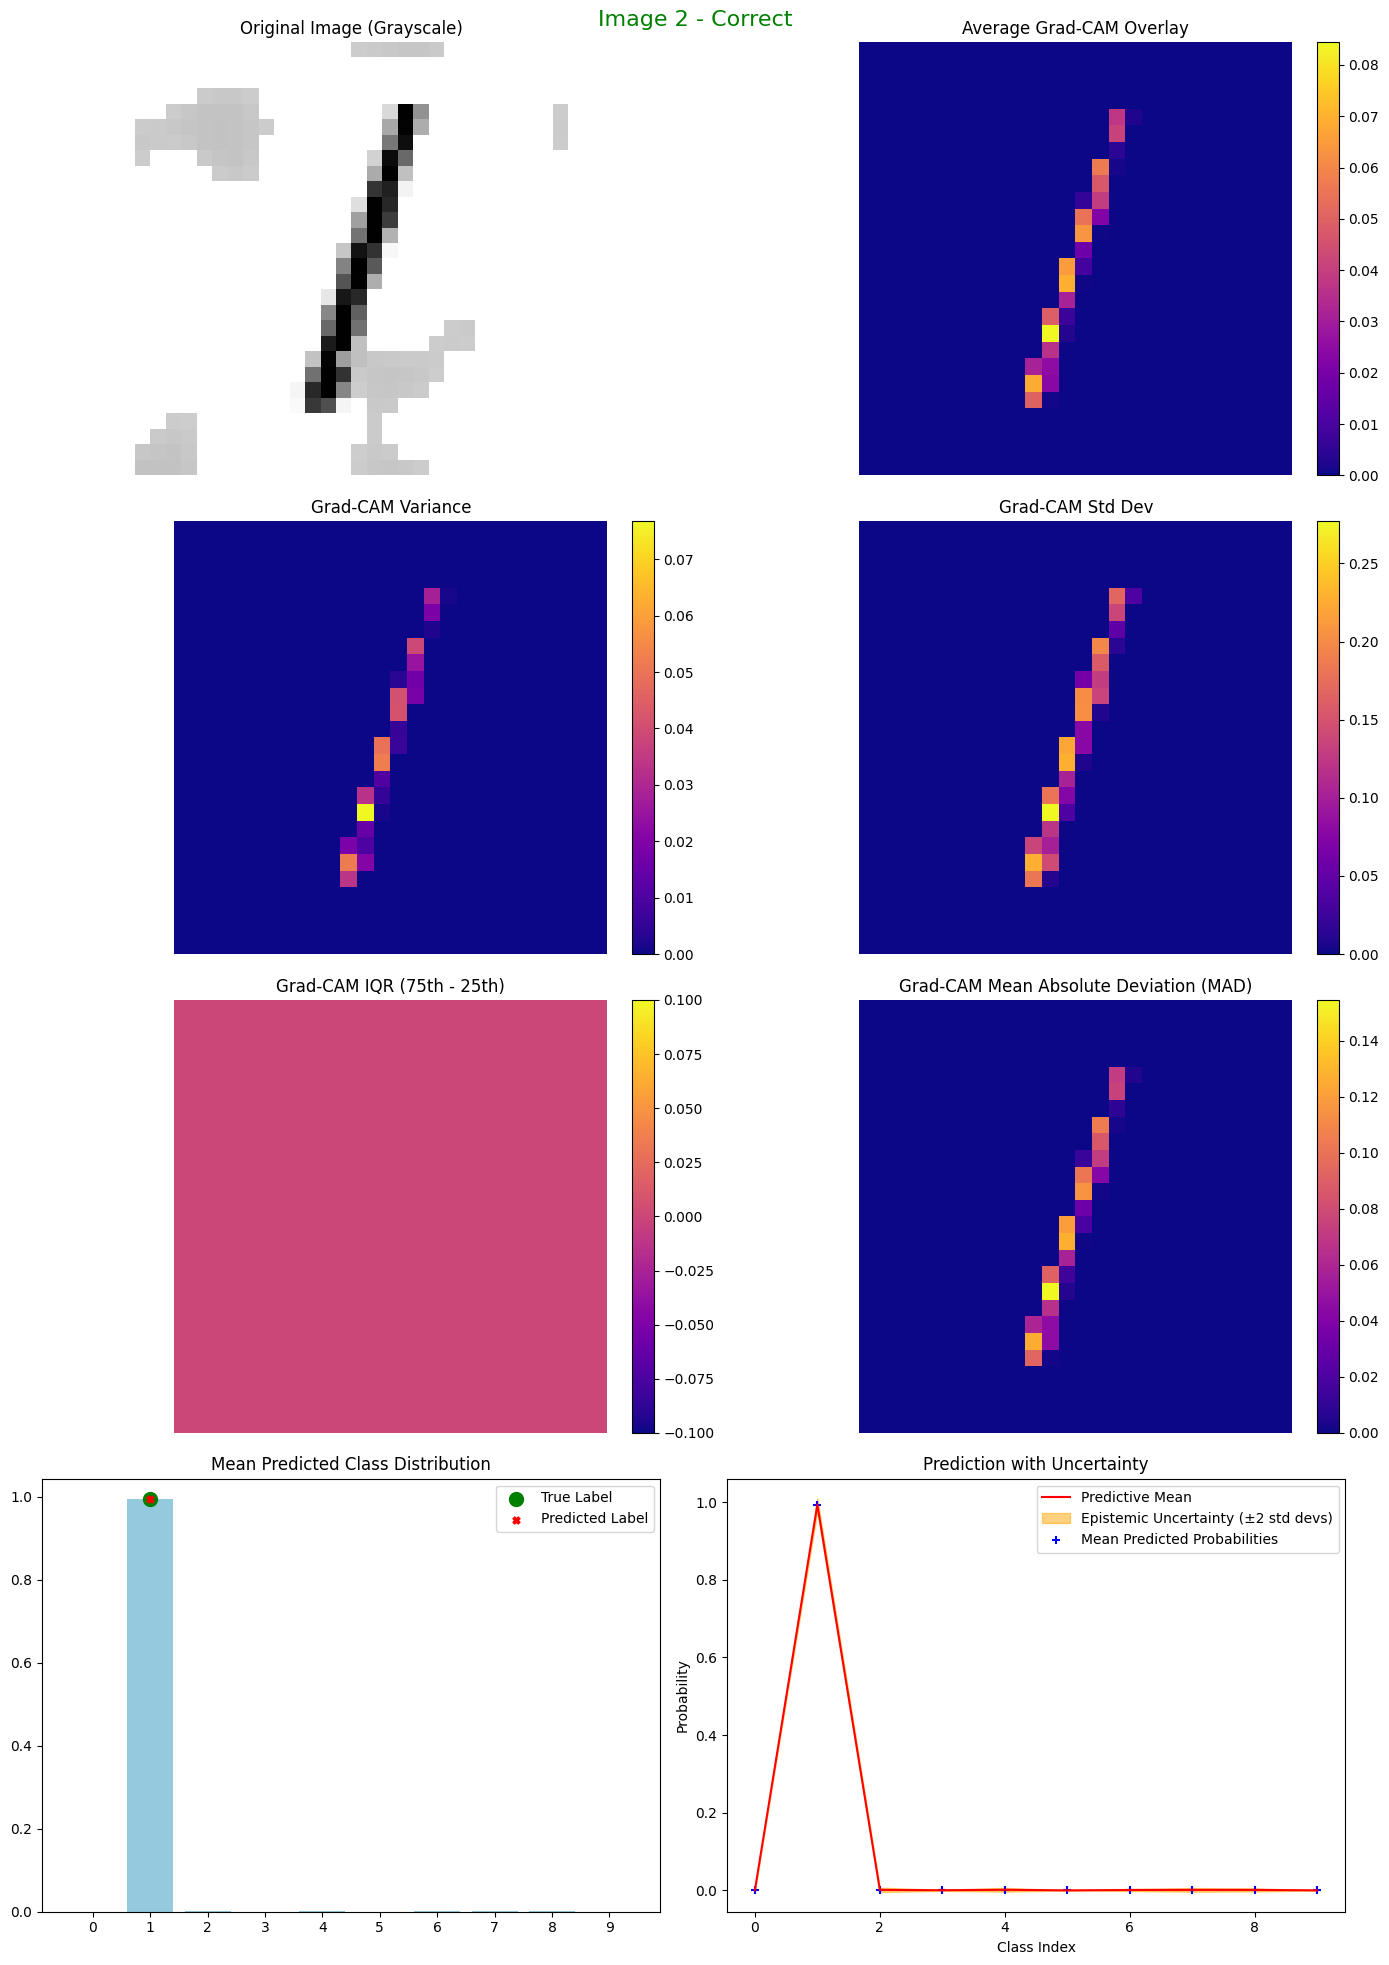

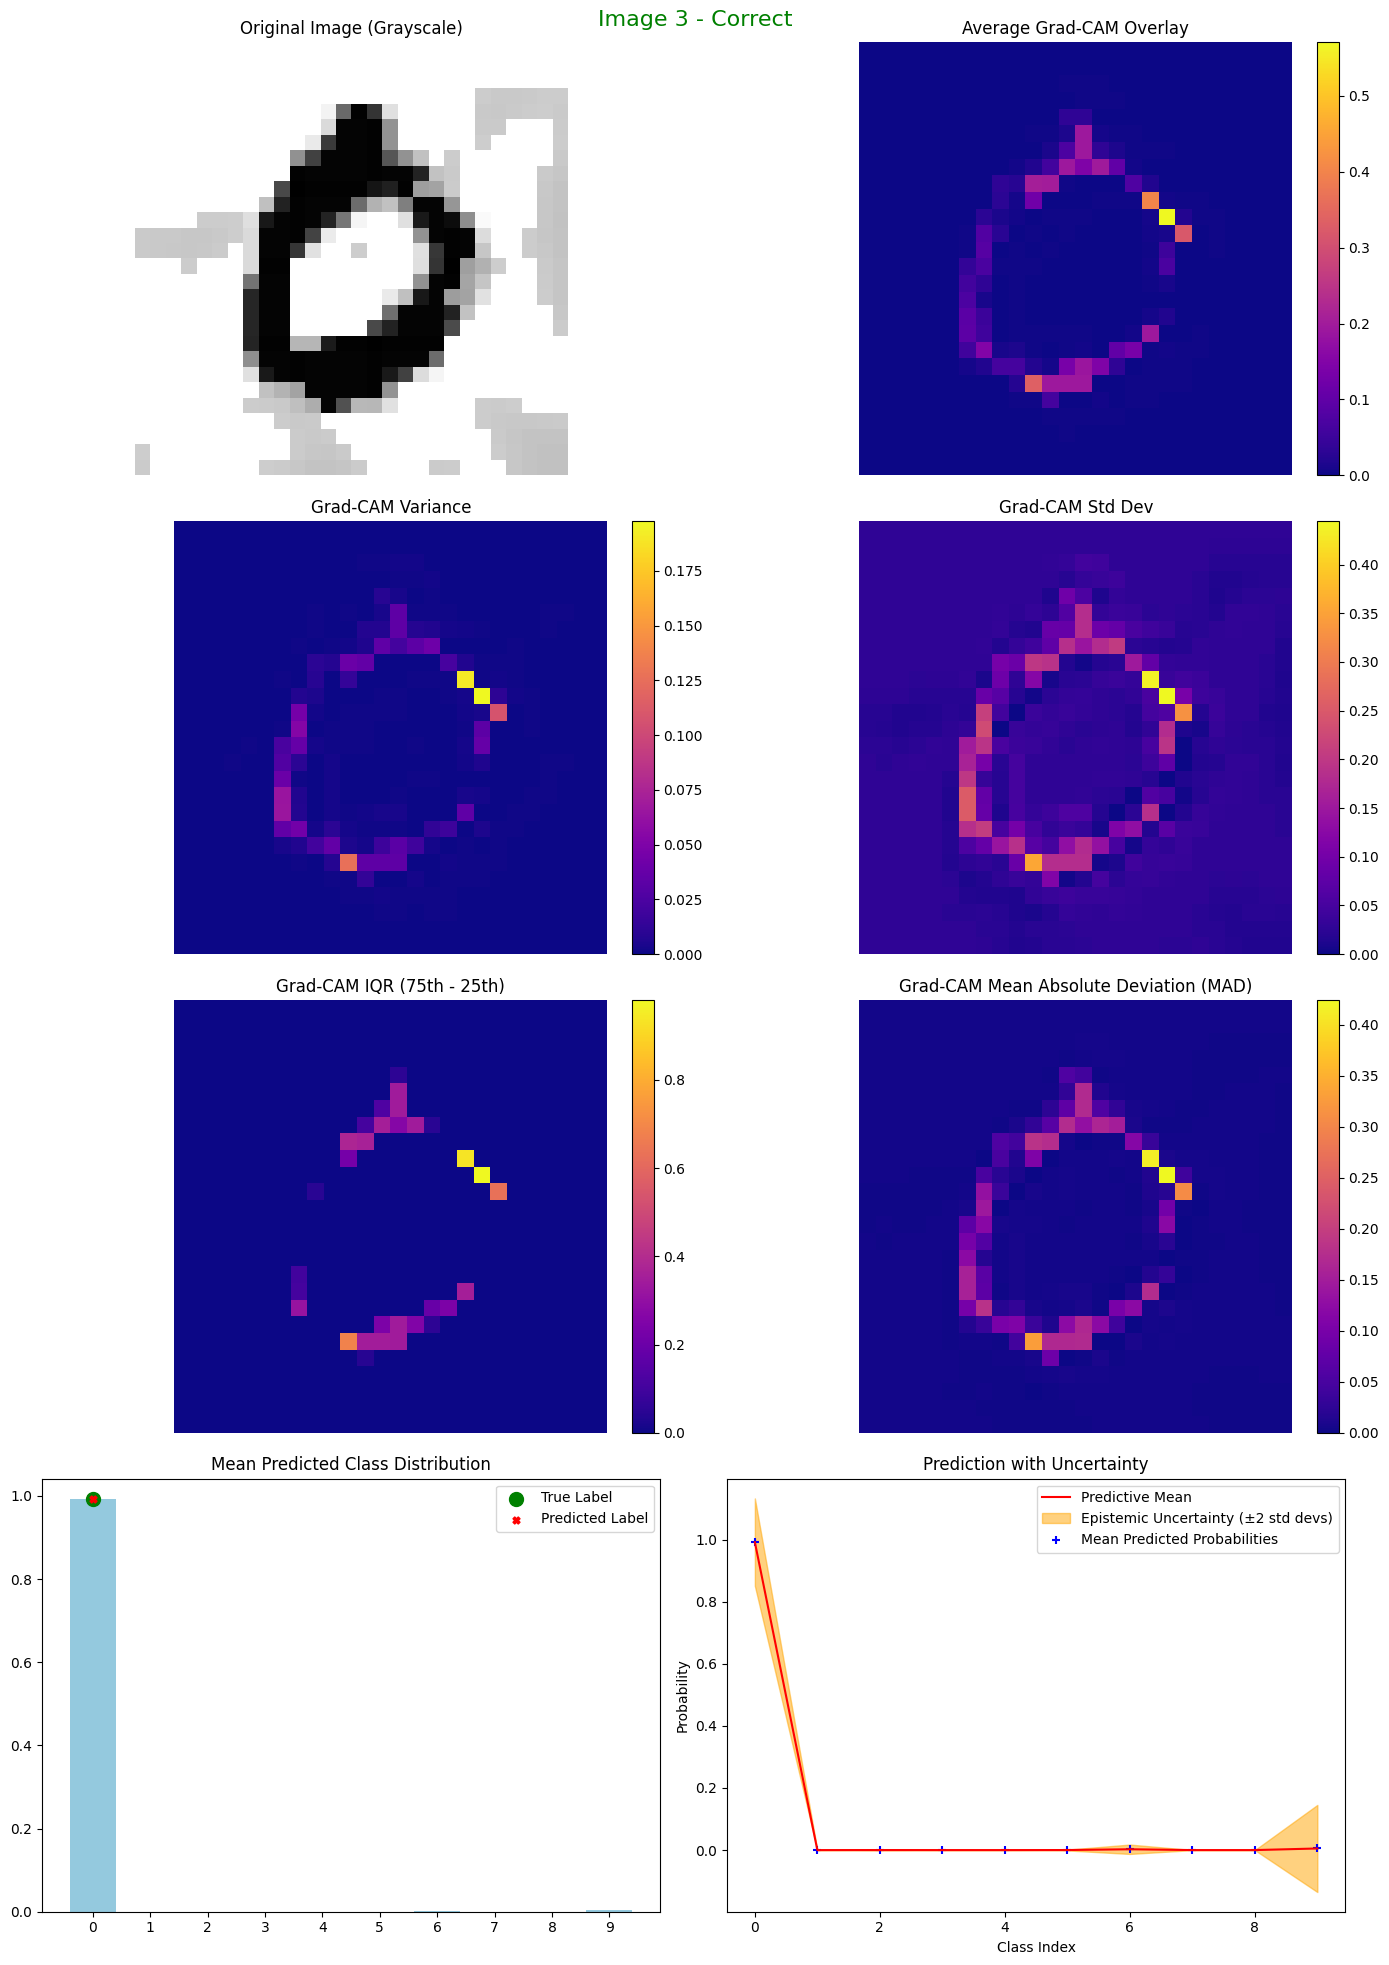

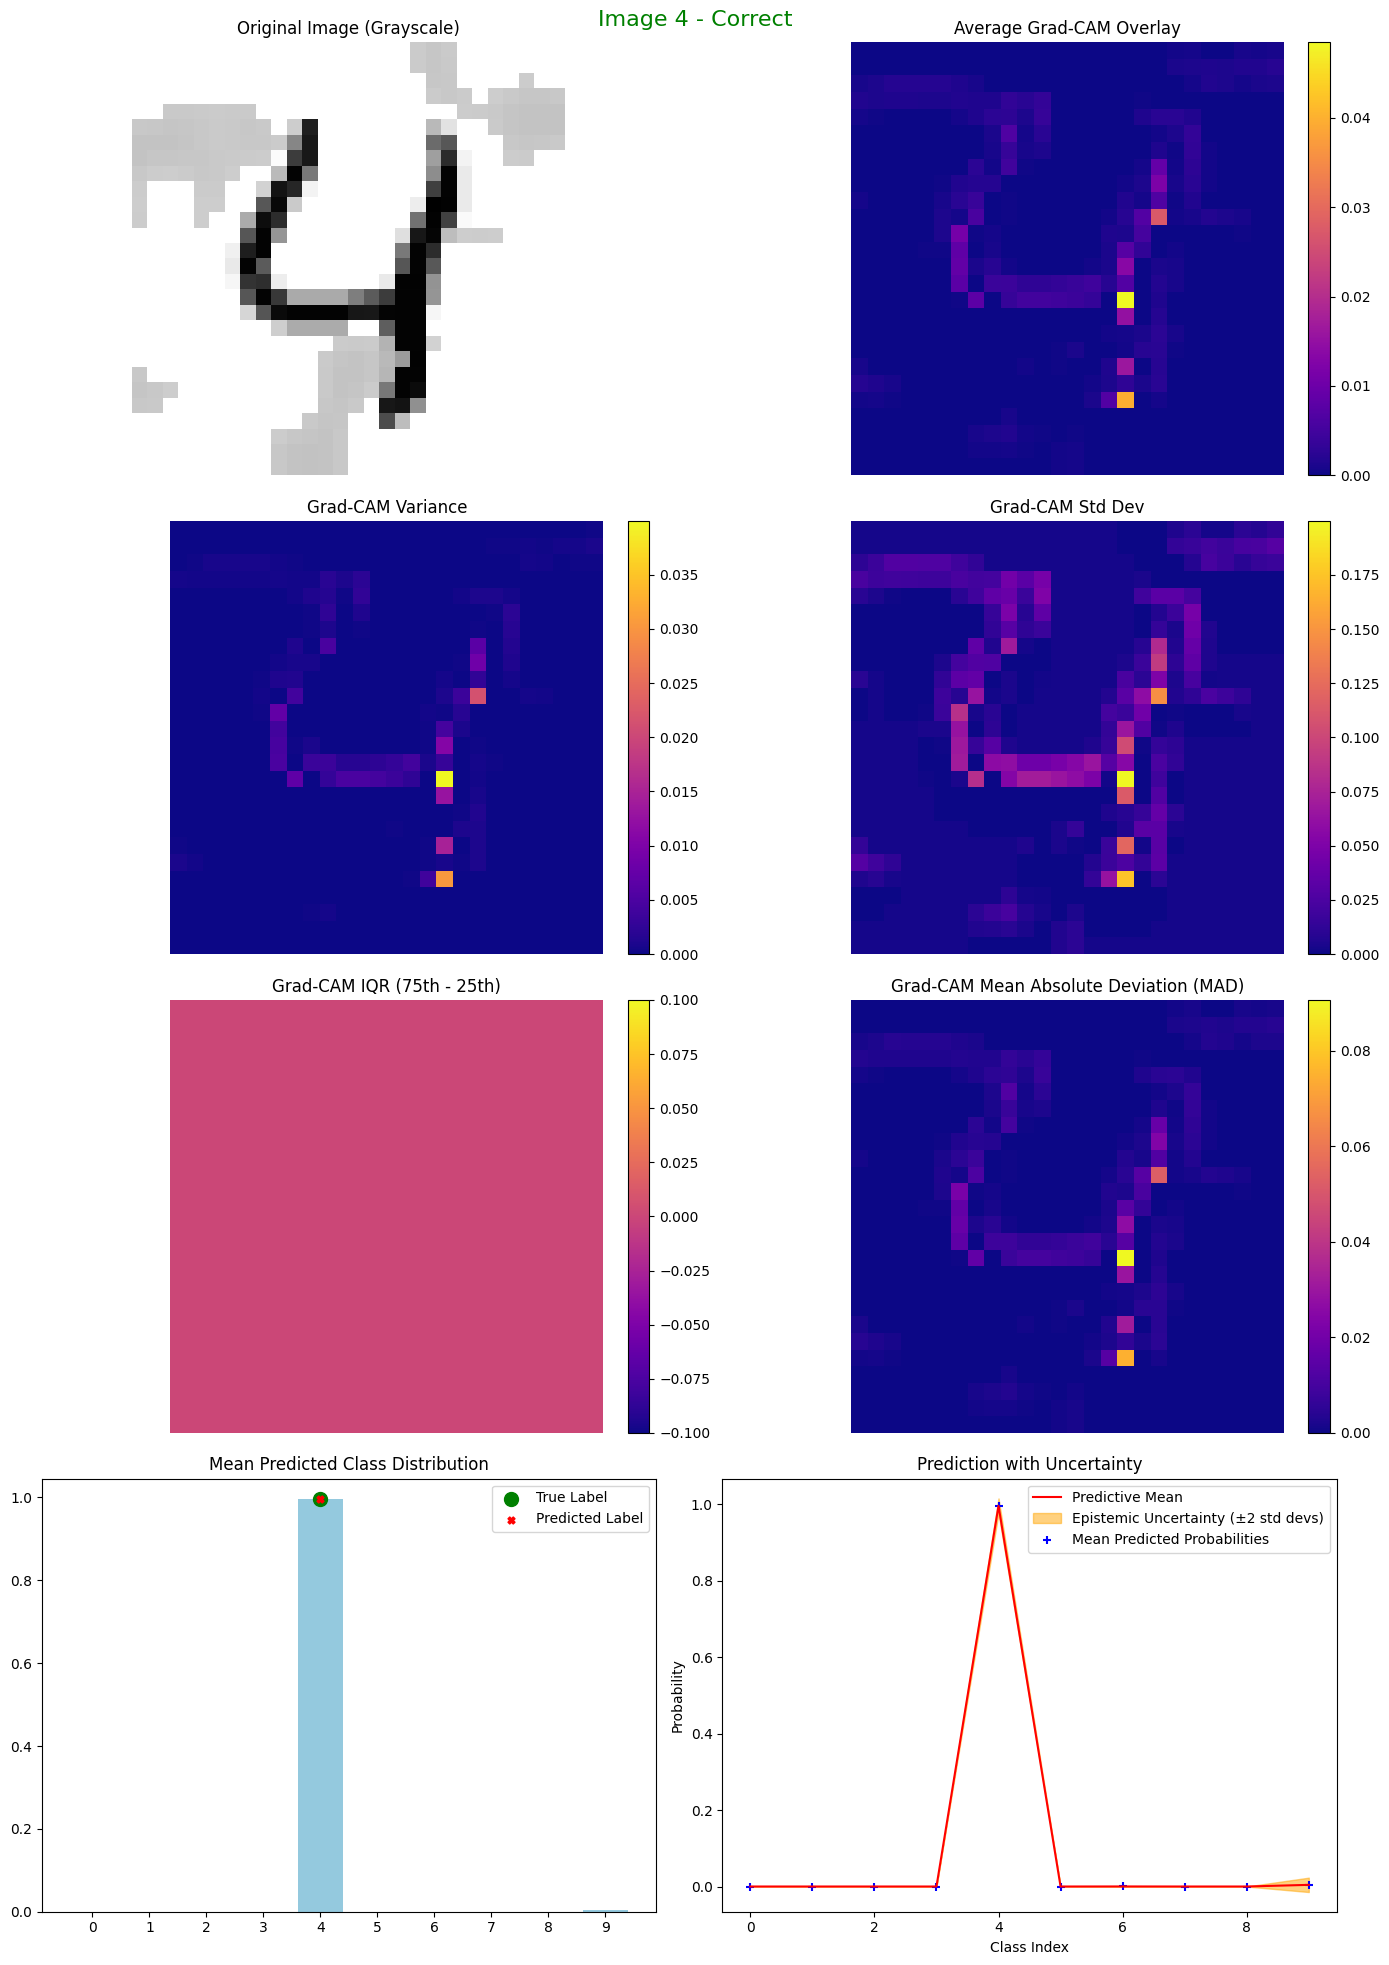

In [121]:
for i in range(5):  # or range(num_samples)
    visualize_image_result(i)


This will create a scatter plot of gradcam variance and entropy for class predictions

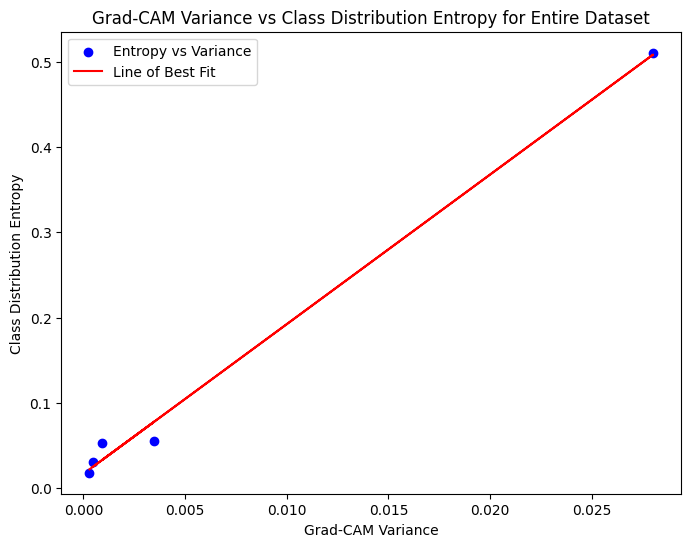

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Initialize lists to store results for plotting
gradcam_variances = []
class_entropy_values = []

# Loop over all samples in the dataset
for index in range(len(predicted_labels)):  # Assuming you have num_samples
    # Get the necessary data for this sample
    img = input_images[index]
    gradcams = gradcam_maps[index]  # Shape: (N_passes, H, W)
    mean_gradcam = np.mean(gradcams, axis=0)

    # Dispersion measures for Grad-CAM
    pixel_variance = np.var(gradcams, axis=0)

    # Calculate entropy or standard deviation for class distribution spread
    mean_prob = np.mean(predicted_probs[index], axis=0)
    prob_entropy = entropy(mean_prob)  # Shannon entropy of the class distribution

    # Grad-CAM variance: mean of pixel variance
    gradcam_variance = np.mean(pixel_variance)

    # Store results for scatter plot
    gradcam_variances.append(gradcam_variance)
    class_entropy_values.append(prob_entropy)

# Convert lists to numpy arrays for convenience
gradcam_variances = np.array(gradcam_variances)
class_entropy_values = np.array(class_entropy_values)

# Plot Grad-CAM variance vs class distribution entropy
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gradcam_variances, class_entropy_values, color='blue', label='Entropy vs Variance')

# Fit a line of best fit using polyfit (degree 1 for a straight line)
slope, intercept = np.polyfit(gradcam_variances, class_entropy_values, 1)
line_of_best_fit = slope * gradcam_variances + intercept

# Plot the line of best fit
ax.plot(gradcam_variances, line_of_best_fit, color='red', label='Line of Best Fit')

# Add labels and title
ax.set_xlabel("Grad-CAM Variance")
ax.set_ylabel("Class Distribution Entropy")
ax.set_title("Grad-CAM Variance vs Class Distribution Entropy for Entire Dataset")
ax.legend()

# Show the plot
plt.show()
